# PDSPL COSMOLOGY FORECAST (w0waCDM, Free Scatter Model)

In [1]:
# =============================================================================
# Forecast for Flat w0waCDM cosmology where the quadrature scatter coefficients
# (c0_floor and c1_slope) are simultaneously INFERRED from the data alongside
# the cosmological parameters — the "Free Scatter" model.
# Only LSST Y10 is analysed here (Appendix C of the paper).
# =============================================================================

In [2]:
# ── Cell 1: Imports ──────────────────────────────────────────────────────────
import pickle
import os
import numpy as np
from astropy.cosmology import Flatw0waCDM
from matplotlib import pyplot as plt

from pdspl_utils.inference import draw_lens_from_given_zs, run_dspl_inference
from pdspl_utils.pairing  import eval_scatter_model
from pdspl_utils.plotting import plot_dspl_corner



POSTERIOR_DIRECTORY = "../data/posteriors/forecast_w0waCDM_free_scatter"
FIGURE_DIRECTORY    = "../figures/forecasts/w0waCDM_free_scatter"
os.makedirs(POSTERIOR_DIRECTORY, exist_ok=True)
os.makedirs(FIGURE_DIRECTORY,    exist_ok=True)

%load_ext autoreload
%autoreload 2

In [3]:

# ── Cell 2: Load pairing results ──────────────────────────────────────────────
with open("../data/samples/pdspl_samples_with_pairs.pkl", "rb") as f:
    pdspl_samples = pickle.load(f)


## Prepare Datasets for the Forecast

In [4]:

# ── Cell 3: Ground truth and cosmology ───────────────────────────────────────
truth = {
    "h0": 70.0, "om": 0.3, "w0": -1.0, "wa": 0.0,
    "lambda_int":  1.0,  "lambda_sigma": 0.05,
    "gamma_pl":    2.0,  "gamma_sigma":  0.16,
    # beta_c0 / beta_c1 set to None → corner plot omits truth lines for them
    "beta_c0": None, "beta_c1": None,
}
# Only H0 is fixed globally; beta_c2 is fixed per-scenario below
fixed_params = {"h0": 70.0}
cosmo_true   = Flatw0waCDM(H0=truth["h0"], Om0=truth["om"], w0=truth["w0"], wa=truth["wa"])


In [5]:
# ── Cell 4: Scenario: LSST Y10 only ──────────────────────────────────────────
key = "lsst_y10"
pa  = pdspl_samples[key]["pairs_analysis"]

scenarios = {
    key: {
        "name":                   f"PDSPL ({pdspl_samples[key]['name']})",
        "down_sampling":          len(pa["pairs_table"]) / 2000,
        "num_lenses":             len(pa["pairs_table"]),
        "color":                  "#2ca02c",
        "coeffs":                 pa["scatter_vs_dissimilarity_fit_coeffs"],
        "fit_type":               pa["scatter_vs_dissimilarity_fit_type"],
        "pairs_table":            pa["pairs_table"],
        "pairs_table_with_errors": pa["pairs_table_with_errors"],
        "redshift_error_rel":     0.03,
        "backend_path":           os.path.join(POSTERIOR_DIRECTORY, f"{key}.h5"),
    }
}

In [6]:
# ── Cell 5: Generate Asimov mock dataset ─────────────────────────────────────
sc           = scenarios[key]
coeffs       = sc["coeffs"]          # [c1_slope, c0_floor] from quadrature fit
fit_type     = sc["fit_type"]
num_samples  = int(sc["num_lenses"] / sc["down_sampling"])
pairs_table  = sc["pairs_table"]
pairs_table_err = sc["pairs_table_with_errors"]
random_indices  = np.random.choice(len(pairs_table), size=num_samples, replace=False)

kwargs_list = []
for i in random_indices:
    z_lens        = pairs_table["z_D"][i]
    z1            = pairs_table["z_S1"][i]
    z2            = pairs_table["z_S2"][i]
    dissimilarity = pairs_table_err["dissimilarity"][i]

    sigma_beta_intrinsic = eval_scatter_model(coeffs, fit_type, dissimilarity)
    sigma_meas_rel       = np.sqrt(0.01 ** 2 + 0.01 ** 2)

    kwargs_list.append(draw_lens_from_given_zs(
        z_lens=z_lens, z1=z1, z2=z2,
        lambda_mst_mean=truth["lambda_int"], lambda_mst_sigma=truth["lambda_sigma"],
        gamma_pl_mean=truth["gamma_pl"],     gamma_pl_sigma=truth["gamma_sigma"],
        sigma_beta_intrinsic=sigma_beta_intrinsic,
        sigma_meas_rel=sigma_meas_rel,
        dissimilarity=dissimilarity,
        down_sampling=sc["down_sampling"],
        with_noise=False,
        cosmo=cosmo_true,
        redshift_error_rel=sc["redshift_error_rel"],
    ))

sc["kwargs_list"] = kwargs_list
print(f"{sc['name']}: {num_samples} mock systems GENERATED")

PDSPL (LSST Y10): 2000 mock systems GENERATED


## Run the Forecast Inference

### Uniform Priors

In [7]:

# ── Cell 6: MCMC — uniform priors, free scatter ──────────────────────────────
#
# Sampled parameters now include beta_c0 (floor) and beta_c1 (slope).
# beta_c2 (quadratic term) is fixed to 0 — not needed for the quadrature model.
#
# Priors on beta_c0 / beta_c1 are broad uniform; initialise walkers near the
# calibrated values so the chain converges quickly.

c0_init = coeffs[1]   # calibrated c0_floor
c1_init = coeffs[0]   # calibrated c1_slope

my_guess = {
    "om":  0.3,  "w0":  -1.0, "wa":  0.0,
    "lambda_int":   1.0,  "lambda_sigma": 0.05,
    "gamma_pl":     2.0,  "gamma_sigma":  0.16,
    "beta_c0": c0_init,   "beta_c1": c1_init,
}
my_spreads = {
    "om":  0.1,  "w0":  0.1, "wa": 0.1,
    "lambda_int":   0.1,  "lambda_sigma": 0.01,
    "gamma_pl":     0.1,  "gamma_sigma":  0.01,
    "beta_c0": 0.01,  "beta_c1": 0.1,
}
my_priors = {
    "h0":           ("uniform", 50.0, 90.0),
    "om":           ("uniform",  0.0,  1.0),
    "w0":           ("uniform", -3.0,  0.0),
    "wa":           ("uniform", -5.0,  5.0),
    "lambda_int":   ("uniform",  0.8,  1.2),
    "lambda_sigma": ("uniform",  0.0,  0.2),
    "gamma_pl":     ("uniform",  1.0,  3.0),
    "gamma_sigma":  ("uniform",  0.0,  0.5),
    "beta_c0":      ("uniform",  0.0,  1.0),   # floor must be non-negative
    "beta_c1":      ("uniform", -5.0,  5.0),
}

fixed_params_sc = fixed_params.copy()
fixed_params_sc["beta_c2"] = 0.0   # fix quadratic term to 0

print("\n--- MCMC: Free Scatter (uniform prior) ---")
samples_free, labels_free = run_dspl_inference(
    sc["kwargs_list"],
    n_walkers=64, n_steps=2000, n_burn=500,
    initial_guess=my_guess,
    fixed_params=fixed_params_sc,
    initial_scatter=my_spreads,
    priors=my_priors,
    backend_path=sc["backend_path"],
)
sc["samples"] = samples_free
param_labels  = labels_free
print(f"  → {sc['name']} DONE")


--- MCMC: Free Scatter (uniform prior) ---
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c2']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma', 'beta_c0', 'beta_c1']


100%|██████████| 2000/2000 [11:44<00:00,  2.84it/s]

  → PDSPL (LSST Y10) DONE


### $\Omega_m$ Gaussian Prior

In [8]:

# ── Cell 7: Ωm Gaussian-prior variant ────────────────────────────────────────
my_priors_om = my_priors.copy()
my_priors_om["om"] = ("gaussian", 0.3, 0.05)

key_prior = key + "_om_prior"
scenarios[key_prior] = sc.copy()
scenarios[key_prior]["name"]         = sc["name"] + r" + $\Omega_m$ Prior"
scenarios[key_prior]["color"]        = "#3e1d03"
scenarios[key_prior]["backend_path"] = os.path.join(POSTERIOR_DIRECTORY, f"{key_prior}.h5")

sc_prior = scenarios[key_prior]
print(f"\n--- MCMC: Free Scatter (Ωm prior) ---\nRunning: {sc_prior['name']}")

samples_prior, _ = run_dspl_inference(
    sc_prior["kwargs_list"],
    n_walkers=64, n_steps=1000, n_burn=500,
    initial_guess=my_guess,
    fixed_params=fixed_params_sc,
    initial_scatter=my_spreads,
    priors=my_priors_om,
    backend_path=sc_prior["backend_path"],
)
sc_prior["samples"] = samples_prior
print(f"  → {sc_prior['name']} DONE")


--- MCMC: Free Scatter (Ωm prior) ---
Running: PDSPL (LSST Y10) + $\Omega_m$ Prior
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'beta_c2']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma', 'beta_c0', 'beta_c1']


100%|██████████| 1000/1000 [06:01<00:00,  2.77it/s]

  → PDSPL (LSST Y10) + $\Omega_m$ Prior DONE


## Plotting the Forecast Results

In [13]:
# ── Cell 8: Plotting ─────────────────────────────────────────────────────────
latex_labels = {
    "om":           r"$\Omega_{\rm m}$",
    "w0":           r"$w_0$",
    "wa":           r"$w_a$",
    "lambda_int":   r"$\overline{\lambda}_{\rm MST}$",
    "lambda_sigma": r"$\sigma({\lambda}_{\rm MST})$",
    "gamma_pl":     r"$\overline{\gamma}_{\rm pl}$",
    "gamma_sigma":  r"$\sigma({\gamma}_{\rm pl})$",
    "beta_c0":      r"$\sigma_{\beta_{\rm E},\rm \mathcal{D}}^{(0)}$",
    "beta_c1":      r"$\sigma_{\beta_{\rm E},\rm \mathcal{D}}^{(1)}$",
}

# Update truth values for free scatter params using calibrated fit coefficients
custom_truths = truth.copy()
custom_truths["beta_c0"] = c0_init   # calibrated floor from quadrature fit
custom_truths["beta_c1"] = c1_init   # calibrated slope from quadrature fit

custom_ranges_free = [
    (0, 1), (-2, 0), (-3, 3),
    (truth["lambda_int"] - 0.1, truth["lambda_int"] + 0.1),
    (0.0, 0.10),
    (truth["gamma_pl"] - 0.1, truth["gamma_pl"] + 0.1),
    (0.12, 0.20),
    (0, 0.25),   # beta_c0
    (0, 2.0),    # beta_c1
]

### LSST Y10 Corner Plot -- With and Without $\Omega_m$ Prior

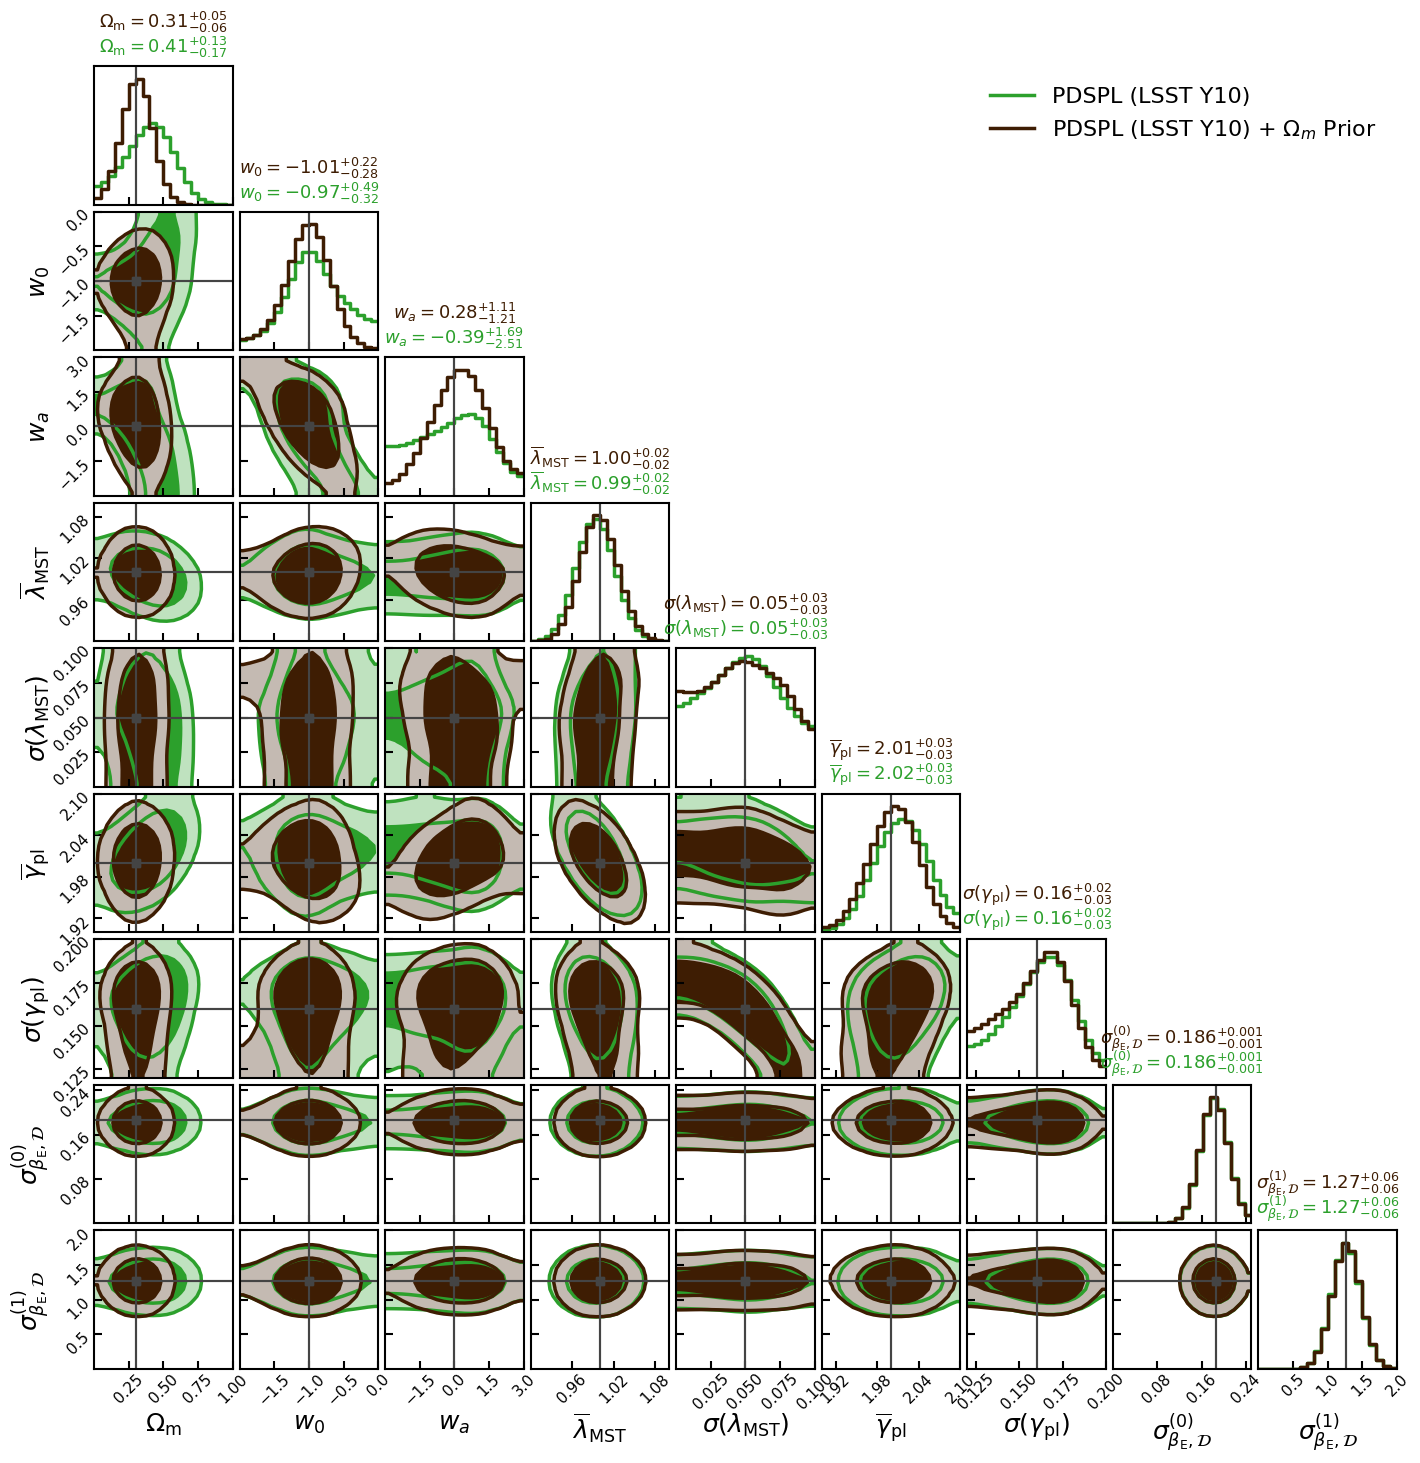

In [14]:
fig = plot_dspl_corner(
    scenarios=scenarios, truth=custom_truths, fixed_params=fixed_params,
    scenarios_to_plot=[key, key_prior],
    custom_ranges=custom_ranges_free,
    latex_labels=latex_labels,
    figsize=(14, 14),
    show_multiple_titles=True,
    save_path=os.path.join(FIGURE_DIRECTORY, "lsst_y10_w0waCDM_free_scatter_forecast.pdf"),
)
plt.show()

## Table of Forecast Results

In [11]:
# ── Cell 9: Parameter summary table ──────────────────────────────────────────
print("\n--- Median ± 1σ Parameter Summary ---")
print(f"{'Scenario':<45} | {'Parameter':<25} | {'Median':>10} | {'-1σ':>10} | {'+1σ':>10}")
print("-" * 110)
for k, sc in scenarios.items():
    if "samples" not in sc:
        continue
    for p_idx, p_key in enumerate(param_labels):
        q16, q50, q84 = np.percentile(sc["samples"][:, p_idx], [16, 50, 84])
        print(f"{sc['name']:<45} | {p_key:<25} | {q50:>10.3f} | {q50-q16:>10.3f} | {q84-q50:>10.3f}")


--- Median ± 1σ Parameter Summary ---
Scenario                                      | Parameter                 |     Median |        -1σ |        +1σ
--------------------------------------------------------------------------------------------------------------
PDSPL (LSST Y10)                              | $\Omega_m$                |      0.407 |      0.172 |      0.125
PDSPL (LSST Y10)                              | $w_0$                     |     -0.973 |      0.321 |      0.493
PDSPL (LSST Y10)                              | $w_a$                     |     -0.392 |      2.515 |      1.688
PDSPL (LSST Y10)                              | $\bar{\lambda}_{\rm int}$ |      0.993 |      0.019 |      0.020
PDSPL (LSST Y10)                              | $\sigma({\lambda}_{\rm int})$ |      0.051 |      0.031 |      0.031
PDSPL (LSST Y10)                              | $\bar{\gamma}_{\rm pl}$   |      2.015 |      0.034 |      0.033
PDSPL (LSST Y10)                              | $\sigma

In [12]:
# ── Cell 10: Save ────────────────────────────────────────────────────────────
with open("../data/samples/forecast_scenarios_w0waCDM_free_scatter_lsst_y10.pkl", "wb") as f:
    pickle.dump(scenarios, f)
print("Saved forecast_scenarios_w0waCDM_free_scatter_lsst_y10.pkl")

Saved forecast_scenarios_w0waCDM_free_scatter_lsst_y10.pkl
